#Ejercicio 2. Dataset Palmer Archipelago

##Analisis Exploratorio de los Datos

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Cargamos el dataset
df = pd.read_csv('penguins.csv')

# Visualizamos las primeras filas y la estructura técnica
print("Dimensiones del dataset:", df.shape)
display(df.head())
df.info()

Dimensiones del dataset: (344, 9)


,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         344 non-null    int64  
 1   species            344 non-null    object 
 2   island             344 non-null    object 
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    object 
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 24.3+ KB


In [13]:
# Resumen estadístico de variables numéricas
display(df.describe())

# Identificación de valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

,Unnamed: 0,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,344.000000,342.000000,342.000000,342.000000,342.000000,344.000000
mean,172.500000,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,99.448479,5.459584,1.974793,14.061714,801.954536,0.818356
min,1.000000,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,86.750000,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,172.500000,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,258.250000,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,344.000000,59.600000,21.500000,231.000000,6300.000000,2009.000000



Valores nulos por columna:
Unnamed: 0            0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


/tmp/ipykernel_152/1036319110.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='species', palette='viridis')


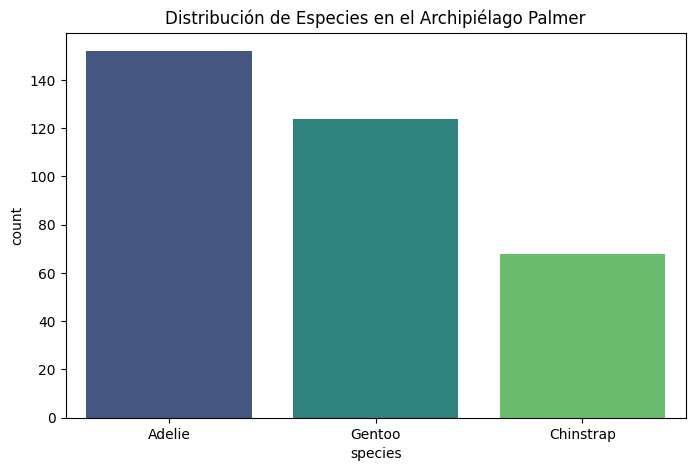

species
Adelie       44.186047
Gentoo       36.046512
Chinstrap    19.767442
Name: proportion, dtype: float64


In [14]:
#Analisis de Variable Objetivo
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='species', palette='viridis')
plt.title('Distribución de Especies en el Archipiélago Palmer')
plt.show()

# Proporción exacta
print(df['species'].value_counts(normalize=True) * 100)

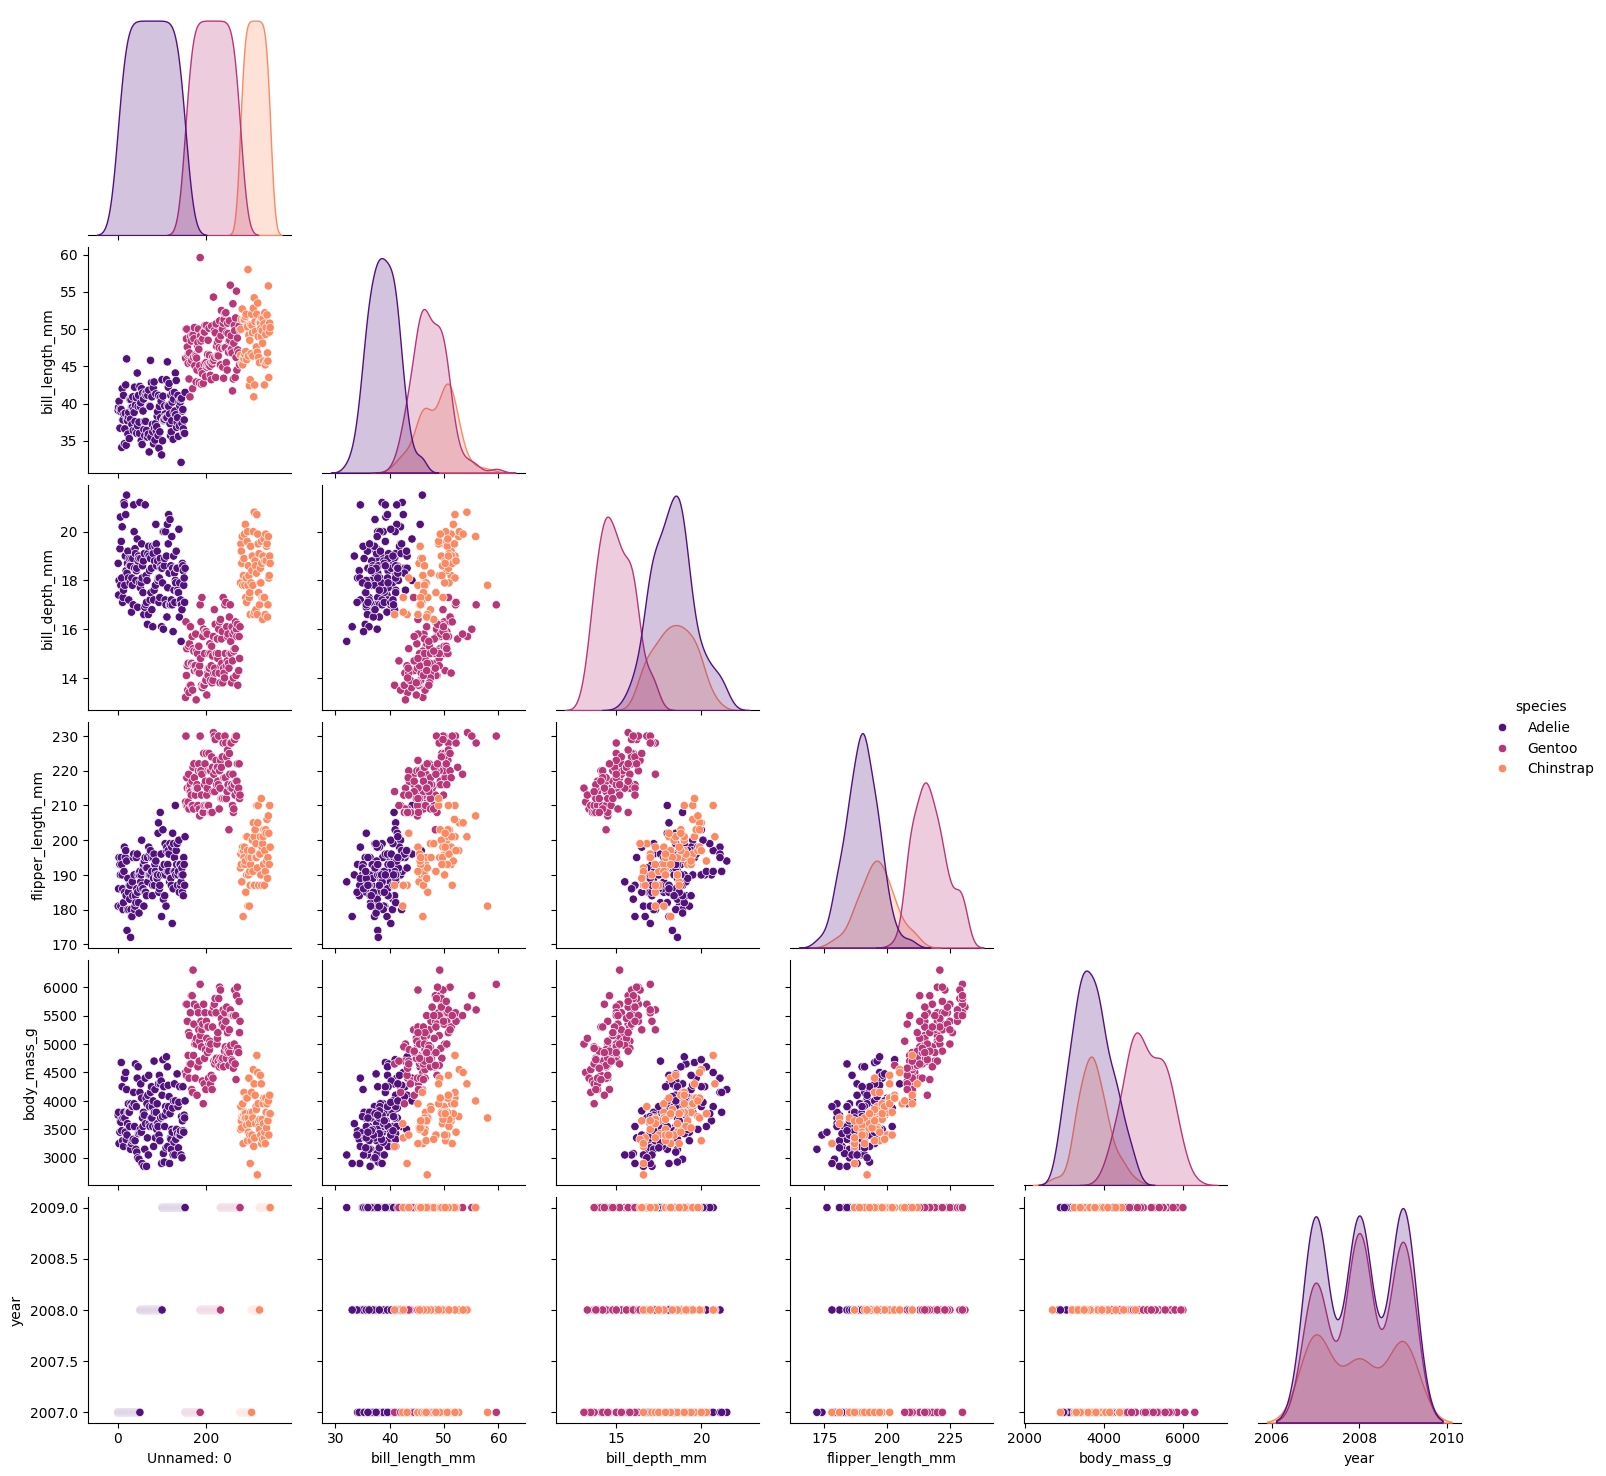

In [15]:
#Analisis Multivariado para ver la relación entre todas las variables numéricas
sns.pairplot(df, hue='species', corner=True, palette='magma')
plt.show()

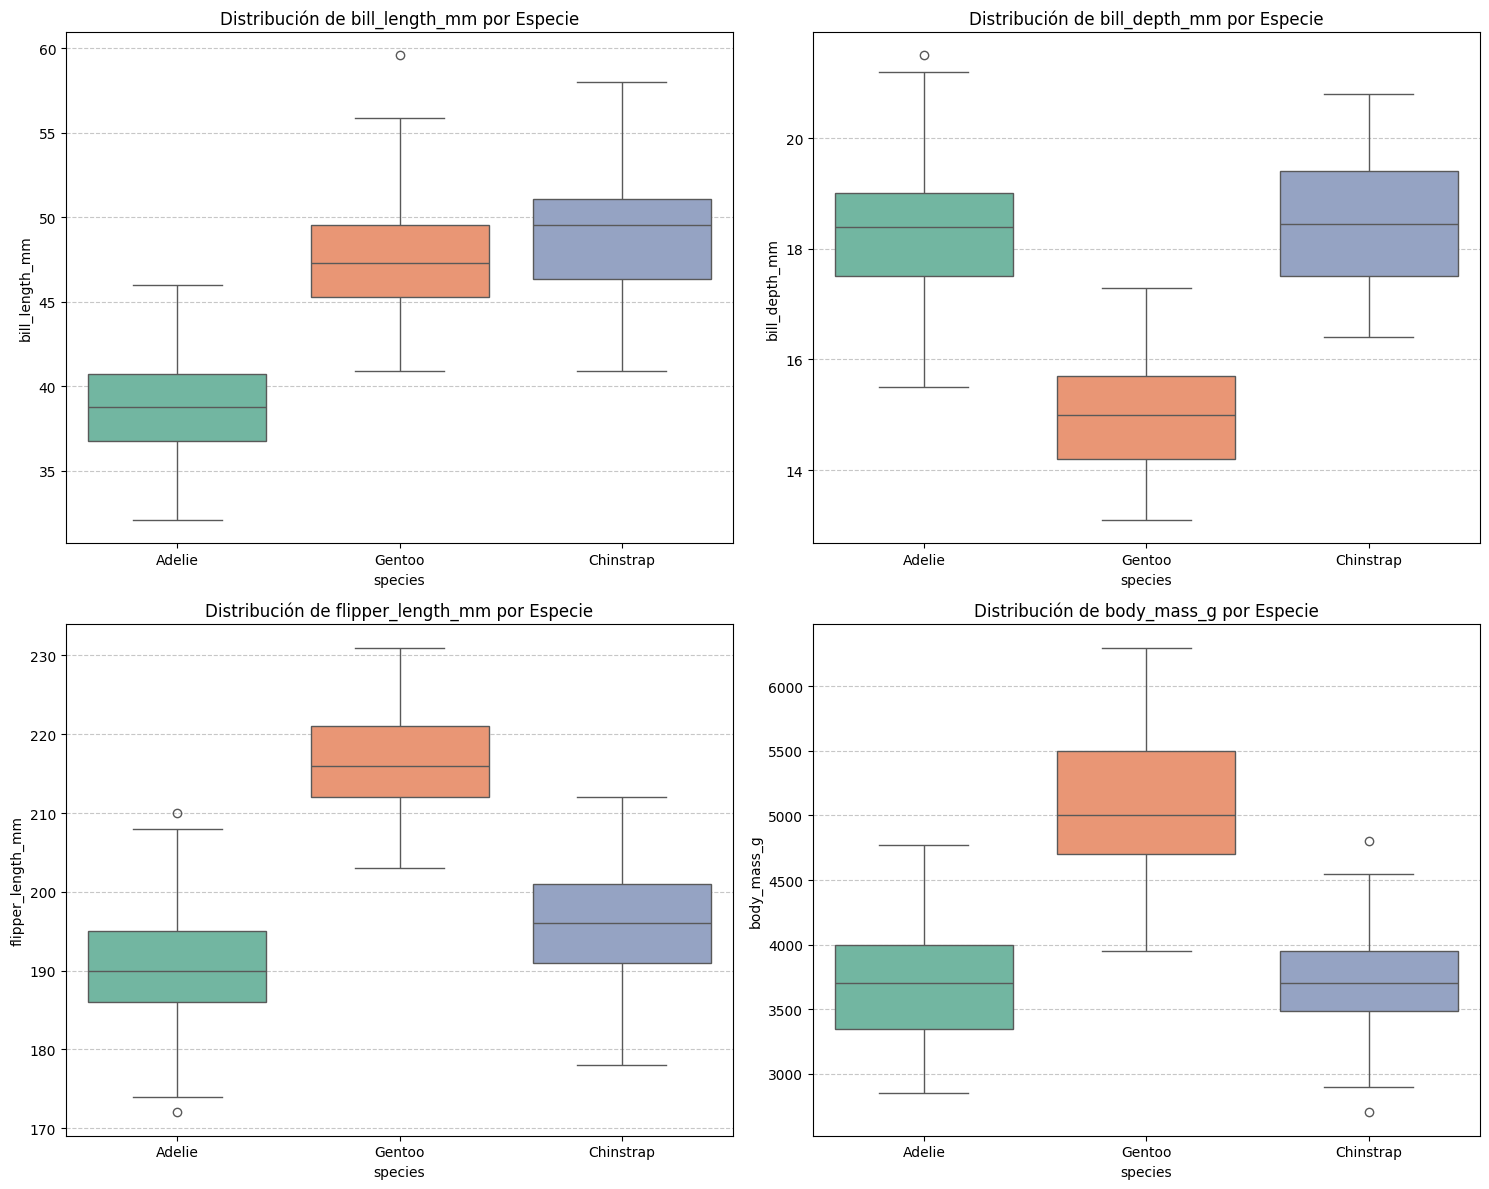

In [16]:
#Revision de Outliers

# Definimos las variables numéricas a analizar
features_num = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Configuramos la cuadrícula de gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features_num):
    sns.boxplot(ax=axes[i], data=df, x='species', y=col, palette='Set2', hue='species', legend=False)
    axes[i].set_title(f'Distribución de {col} por Especie')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##Limpieza de los Datos

In [17]:
# 1. Eliminamos columnas no relevantes (el índice inicial y el año)
# Nota: La primera columna suele cargarse como 'Unnamed: 0' si no se especifica el índice
df_cleaned = df.drop(columns=['Unnamed: 0', 'year'], errors='ignore')

# 2. Eliminamos las filas con valores nulos
# Al ser una cantidad pequeña, no perdemos mucha información
df_cleaned = df_cleaned.dropna()

# 3. Verificamos que no queden nulos y el nuevo tamaño del dataset
print(f"Tamaño original: {df.shape}")
print(f"Tamaño tras la limpieza: {df_cleaned.shape}")
print("\nConteo de nulos final:")
print(df_cleaned.isnull().sum())

# 4. Mostramos el balance de clases final para confirmar que se mantiene la proporción
print("\nBalance de clases tras limpieza:")
print(df_cleaned['species'].value_counts(normalize=True) * 100)

Tamaño original: (344, 9)
Tamaño tras la limpieza: (333, 7)

Conteo de nulos final:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

Balance de clases tras limpieza:
species
Adelie       43.843844
Gentoo       35.735736
Chinstrap    20.420420
Name: proportion, dtype: float64


##Entrenamiento del Modelo

In [18]:
# Aplicamos One-Hot Encoding a las variables categóricas (island y sex)
# El parámetro drop_first=True evita la multicolinealidad (opcional en árboles, pero buena práctica)
df_final = pd.get_dummies(df_cleaned, columns=['island', 'sex'], drop_first=True)

# Definimos nuestras Features (X) y el Target (y)
X = df_final.drop('species', axis=1)
y = df_final['species']

# Dividimos en entrenamiento (80%) y prueba (20%)
# Usamos stratify=y para asegurar que la proporción de especies se mantenga en ambos sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Set de entrenamiento: {X_train.shape}")
print(f"Set de prueba: {X_test.shape}")

Set de entrenamiento: (266, 7)
Set de prueba: (67, 7)


In [19]:
# Instanciamos el modelo
# Usamos un random_state para que los resultados sean reproducibles
clf = DecisionTreeClassifier(random_state=42)

# Entrenamos
clf.fit(X_train, y_train)

# Realizamos las predicciones
y_pred = clf.predict(X_test)

In [20]:
# Generamos el reporte de clasificación
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# F1-Score pesado (weighted) para ver el rendimiento global considerando el desbalance
f1_global = f1_score(y_test, y_pred, average='weighted')
print(f"\nF1-Score Global (Weighted): {f1_global:.4f}")

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      Adelie       0.93      0.97      0.95        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.96      0.96      0.96        67
weighted avg       0.96      0.96      0.96        67


F1-Score Global (Weighted): 0.9552


/tmp/ipykernel_152/2596112747.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma', ax=ax2)


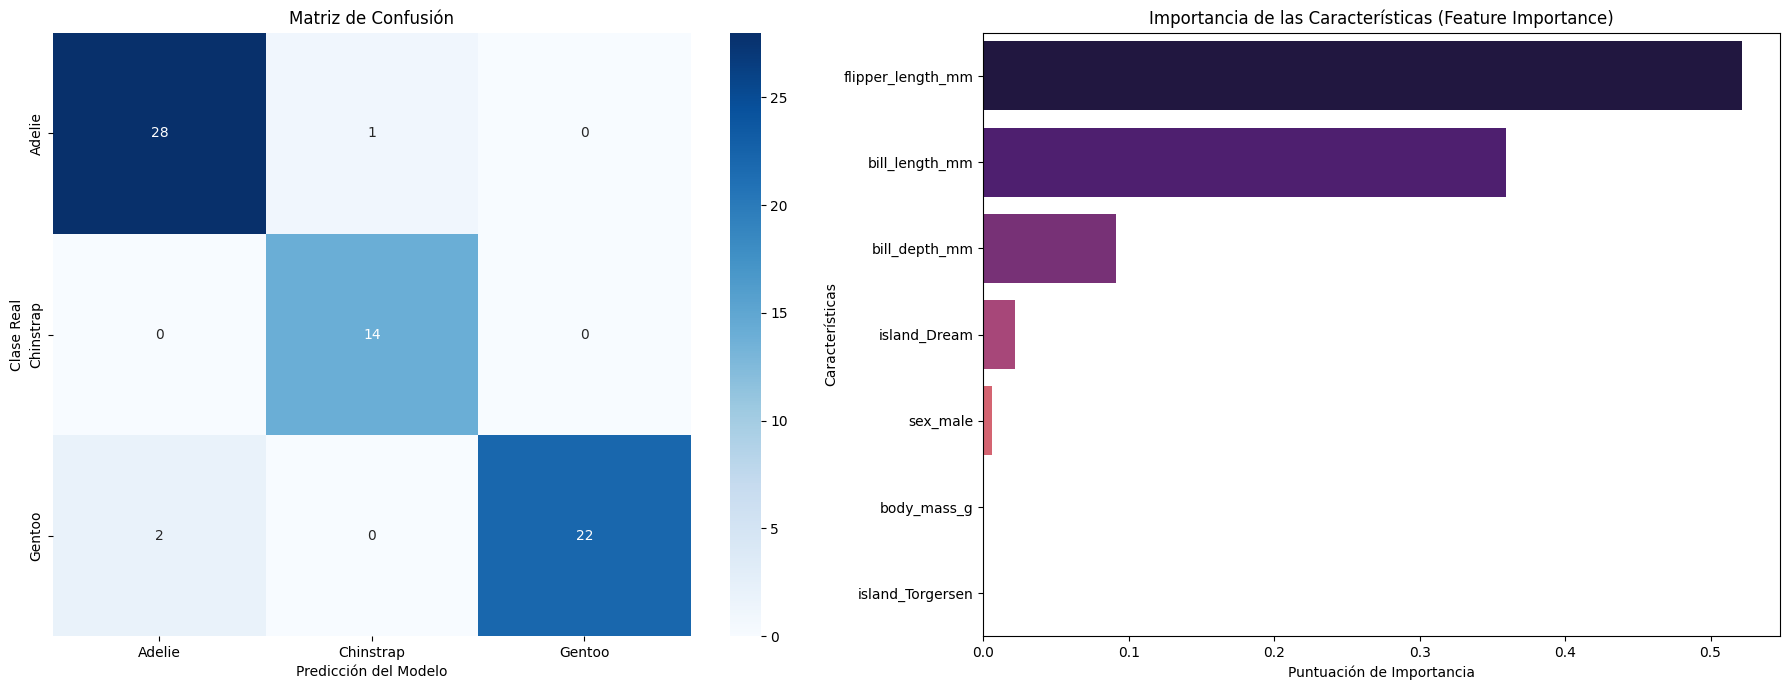

In [21]:
# Creamos una figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- 1. MATRIZ DE CONFUSIÓN ---
# Nos permite ver si el modelo confunde especies con características similares
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=clf.classes_, yticklabels=clf.classes_)
ax1.set_title('Matriz de Confusión')
ax1.set_xlabel('Predicción del Modelo')
ax1.set_ylabel('Clase Real')

# --- 2. IMPORTANCIA DE LAS CARACTERÍSTICAS ---
# ¿En qué se fijó más el árbol? (Aletas, pico, peso, isla...)
importances = clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma', ax=ax2)
ax2.set_title('Importancia de las Características (Feature Importance)')
ax2.set_xlabel('Puntuación de Importancia')
ax2.set_ylabel('Características')

plt.tight_layout()
plt.show()